In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv('netflix_customer_churn.csv')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [20]:
features = [
    'age','gender','subscription_type','watch_hours','last_login_days',
    'region','monthly_fee','number_of_profiles','avg_watch_time_per_day'
]

In [21]:
# Independent variables (features)
X = df.drop(columns=['churned'])

# Dependent variable (target)
y = df['churned']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
cat_cols = ['gender','subscription_type','region']
num_cols = ['age','watch_hours','last_login_days','monthly_fee',
            'number_of_profiles','avg_watch_time_per_day']


In [24]:
# Preprocessor: OHE for categoricals, Standardize numerics
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols),
    ]
)

In [26]:
#  Pipeline: preprocessing + model
from sklearn.pipeline import Pipeline
pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [28]:
pipe.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender',
                                                   'subscription_type',
                                                   'region']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'watch_hours',
                                                   'last_login_days',
                                                   'monthly_fee',
                                                   'number_of_profiles',
                                                   'avg_watch_time_per_day'])])),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

In [29]:
# Evaluate
y_pred = pipe.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

[[430  67]
 [ 48 455]]
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       497
           1       0.87      0.90      0.89       503

    accuracy                           0.89      1000
   macro avg       0.89      0.88      0.88      1000
weighted avg       0.89      0.89      0.88      1000

ROC-AUC: 0.8848818557468069


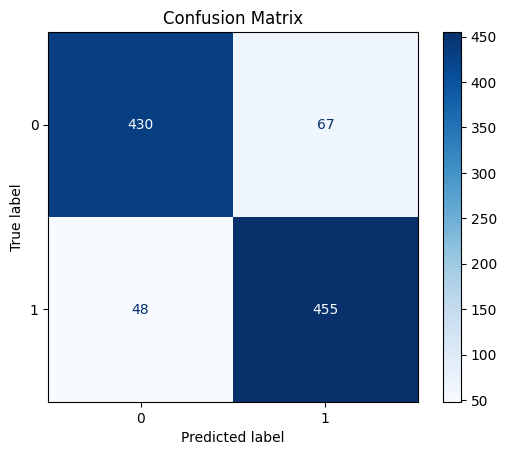

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


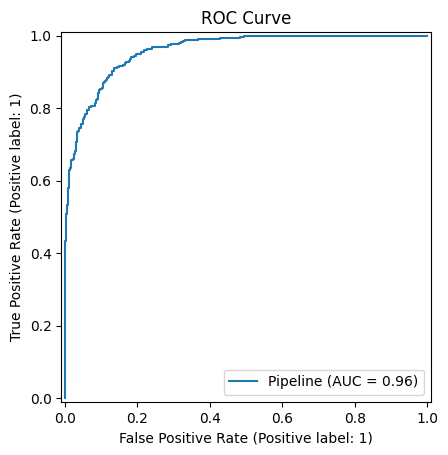

In [31]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(pipe, X_test, y_test)
plt.title("ROC Curve")
plt.show()

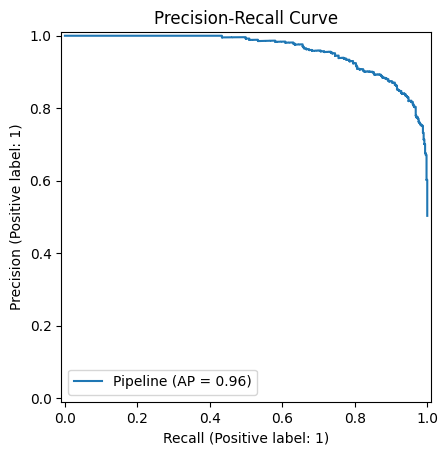

In [34]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test)
plt.title("Precision-Recall Curve")
plt.show()

In [35]:
import pandas as pd

# Get feature names after preprocessing
feature_names = pipe.named_steps['prep'].get_feature_names_out()

# Extract coefficients from the logistic regression model
coefficients = pipe.named_steps['clf'].coef_[0]

# Put into a DataFrame
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Importance (abs)': abs(coefficients)
}).sort_values(by='Importance (abs)', ascending=False)

print(feat_imp.head(15))


                            Feature  Coefficient  Importance (abs)
14      num__avg_watch_time_per_day    -4.156393          4.156393
10                 num__watch_hours    -3.412842          3.412842
11             num__last_login_days     2.187911          2.187911
13          num__number_of_profiles    -1.031871          1.031871
3   cat__subscription_type_Standard    -0.857357          0.857357
12                 num__monthly_fee    -0.754834          0.754834
0                  cat__gender_Male    -0.277671          0.277671
8         cat__region_South America     0.155123          0.155123
5                cat__region_Europe     0.149072          0.149072
2    cat__subscription_type_Premium    -0.133787          0.133787
1                 cat__gender_Other    -0.119631          0.119631
6         cat__region_North America    -0.080850          0.080850
4                  cat__region_Asia    -0.077538          0.077538
9                          num__age     0.027964          0.02

/tmp/ipython-input-2376313099.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


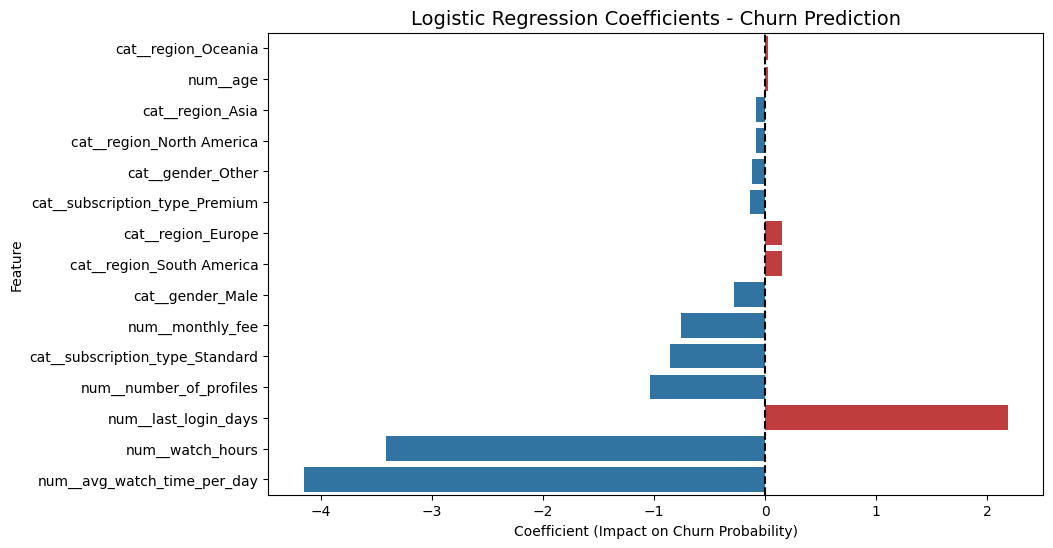

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by absolute importance
feat_imp_sorted = feat_imp.sort_values(by='Importance (abs)', ascending=True)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feat_imp_sorted,
    palette=['#d62728' if c > 0 else '#1f77b4' for c in feat_imp_sorted['Coefficient']]  # red=positive, blue=negative
)
plt.axvline(0, color='black', linestyle='--')
plt.title("Logistic Regression Coefficients - Churn Prediction", fontsize=14)
plt.xlabel("Coefficient (Impact on Churn Probability)")
plt.ylabel("Feature")
plt.show()
